In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

import swift_grbs as sx

c1 = 'cornflowerblue'
c2 = 'navy'
c3 = 'rebeccapurple'
c4 = '#CF6275'
c5 = 'maroon'

In [2]:
# 1. refresh the master list once (saves swift_grb_list.csv next to the notebook)
cat = sx.update_grb_list("swift_grb_list.csv")


saved 1536 GRBs -> swift_grb_list.csv


In [3]:
# 2. browse / filter however you like
cat[cat.has_position]                      # only localised bursts
cat.sort_values("z_limit").head(10)        # candidate high-z bursts
cat[cat.name.str.startswith("GRB2601")]    # by epoch

,trigger,target_id,name,ra,dec,pos_err_arcsec,enhanced,z_limit,has_position,curve_url
0,1444088,01444088,GRB260127A,15 27 31.11,+06 45 45.4,1.9,Yes,3.6,True,https://www.swift.ac.uk/xrt_curves/01444088/
1,1442454,01442454,GRB260120B,18 58 38.42,+61 54 18.1,3.6,No,2.9,True,https://www.swift.ac.uk/xrt_curves/01442454/
3,1440319,01440319,GRB260114A,04 58 23.49,-08 00 51.9,3.2,Yes,NaN,True,https://www.swift.ac.uk/xrt_curves/01440319/
4,1439093,01439093,GRB260113A,<NA>,<NA>,NaN,<NA>,NaN,False,https://www.swift.ac.uk/xrt_curves/01439093/
6,1434591,01434591,GRB260109C,<NA>,<NA>,NaN,<NA>,NaN,False,https://www.swift.ac.uk/xrt_curves/01434591/
7,1430212,01430212,GRB260104A,22 29 35.77,-21 17 43.2,2.1,Yes,2.8,True,https://www.swift.ac.uk/xrt_curves/01430212/
8,1429608,01429608,GRB260101A,05 45 42.76,+63 35 31.2,1.9,Yes,3.0,True,https://www.swift.ac.uk/xrt_curves/01429608/


GRB 260120B  (trigger 1442454, target 01442454)
  17 detections, 1 upper limits  <- https://www.swift.ac.uk/xrt_curves/01442454/flux.qdp


/home/gevas/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


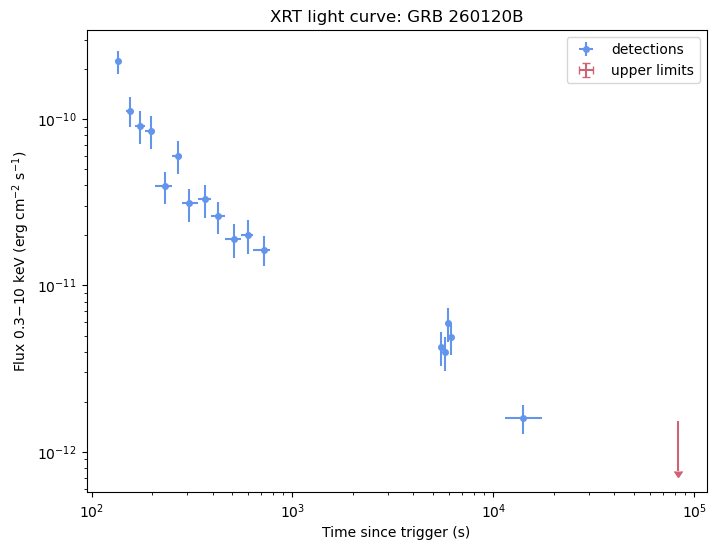

In [4]:
# 3. pick one and go straight to the light curve — trigger feeds show_grb directly
row = cat.iloc[1]
data, det, ul, meta =sx.show_grb(row.trigger)                    # or row.target_id

In [5]:
xf = np.log10(det['t'])
yf = np.log10(det['f'])


x = det['t']
xu = det['tu']
xl = det['tl']

y= det['f']
yu = det['fu']
yl = det['fl']

In [6]:
def lin(x, a, b):
    x = np.array(x)
    return a*x + b

In [7]:
fit_params, pcov = scipy.optimize.curve_fit(lin, xf, yf)
fit_params

array([-0.84810853, -8.22129792])

In [8]:
y_fit2 = lin(xf, *fit_params)

Text(0, 0.5, 'flux')

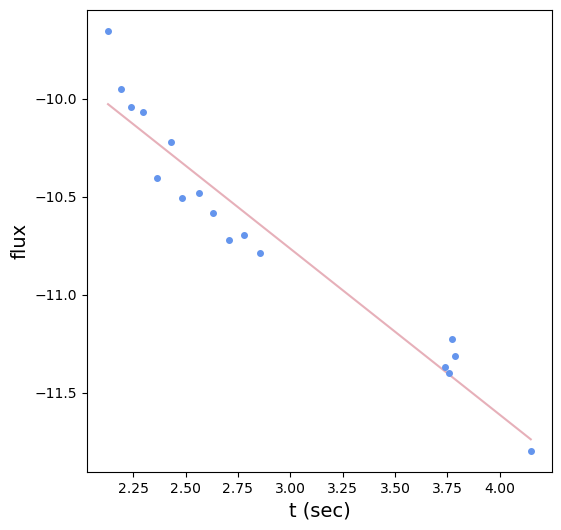

In [9]:
plt.figure(figsize = (6,6))


plt.errorbar(xf,yf,marker='o'
             ,markersize=4,color=c1,ls=' ')


plt.plot(xf, y_fit2,color=c4,alpha=.5,label='lin fit')
# plt.legend()
# plt.xticks(np.arange(0,20,2))
plt.xlabel('t (sec)',fontsize=14)
plt.ylabel('flux',fontsize=14)

# plt.yscale('log')
# plt.xscale('log')